# 1. Setup and Synthetic Noise Generation
We'll load the data and programmatically add "salt and pepper" style Gaussian noise.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, losses
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model

# Load data
(x_train, _), (x_test, _) = fashion_mnist.load_data()

# Normalize and add a channel dimension for Convolutional layers
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

# Add random Gaussian noise
noise_factor = 0.1
x_train_noisy = x_train + noise_factor * tf.random.normal(shape=x_train.shape)
x_test_noisy = x_test + noise_factor * tf.random.normal(shape=x_test.shape)

# Clip values to keep them in [0, 1] range
x_train_noisy = tf.clip_by_value(x_train_noisy, clip_value_min=0., clip_value_max=1.)
x_test_noisy = tf.clip_by_value(x_test_noisy, clip_value_min=0., clip_value_max=1.)

# 2. Building a Convolutional DAE
For denoising, Convolutional Neural Networks (CNNs) perform much better than simple Dense layers because they leverage spatial relationships in the image.


In [ ]:
class Denoise(Model):
  def __init__(self):
    super(Denoise, self).__init__()
    # Encoder: Downsampling
    self.encoder = tf.keras.Sequential([
      layers.Input(shape=(28, 28, 1)),
      layers.Conv2D(16, (3, 3), activation='relu', padding='same', strides=2),
      layers.Conv2D(8, (3, 3), activation='relu', padding='same', strides=2)
    ])

    # Decoder: Upsampling
    self.decoder = tf.keras.Sequential([
      layers.Conv2DTranspose(8, kernel_size=3, strides=2, activation='relu', padding='same'),
      layers.Conv2DTranspose(16, kernel_size=3, strides=2, activation='relu', padding='same'),
      layers.Conv2D(1, kernel_size=(3, 3), activation='sigmoid', padding='same')
    ])

  def call(self, x):
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded

autoencoder = Denoise()
autoencoder.compile(optimizer='adam', loss=losses.MeanSquaredError())


# 3. Training: Mapping Noisy to Clean
Note that we fit using x_train_noisy as the input and the original x_train as the target.


In [ ]:
autoencoder.fit(x_train_noisy, x_train,
                epochs=2,
                shuffle=True,
                validation_data=(x_test_noisy, x_test))


Epoch 1/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 27ms/step - loss: 0.0209 - val_loss: 0.0203
Epoch 2/2
 217/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 22ms/step - loss: 0.0203

KeyboardInterrupt: 

# 4. Visualizing the Denoising Power
We compare the noisy input we gave the model against the cleaned output it produced.


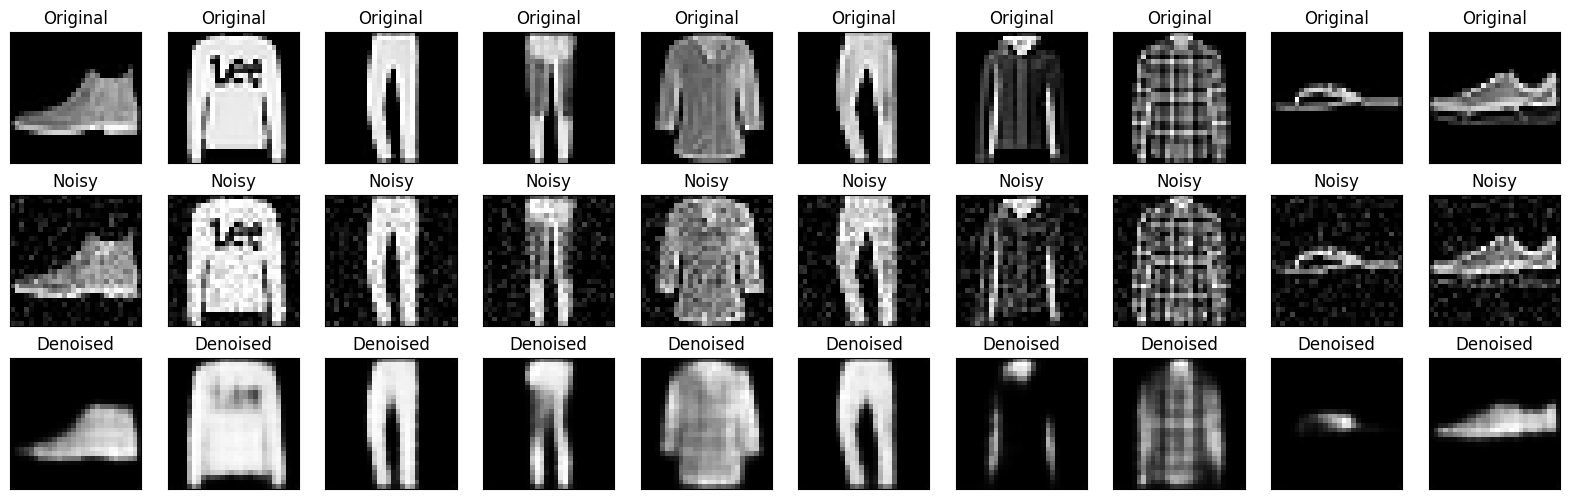

In [ ]:
encoded_imgs = autoencoder.encoder(x_test_noisy).numpy()
decoded_imgs = autoencoder.decoder(encoded_imgs).numpy()

n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    # Display Original
    ax = plt.subplot(3, n, i + 1)
    plt.title("Original")
    plt.imshow(tf.squeeze(x_test[i]))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display Noisy Input
    ax = plt.subplot(3, n, i + n + 1)
    plt.title("Noisy")
    plt.imshow(tf.squeeze(x_test_noisy[i]))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display Denoised Output
    bx = plt.subplot(3, n, i + 2 * n + 1)
    plt.title("Denoised")
    plt.imshow(tf.squeeze(decoded_imgs[i]))
    plt.gray()
    bx.get_xaxis().set_visible(False)
    bx.get_yaxis().set_visible(False)
plt.show()